# CaloClouds 3

In [1]:
import h5py
import numpy as np
import glob
import os
from matplotlib import pyplot as plt
from src.evaluation.plotting import blank_axes

In [2]:
loaded = h5py.File("/data/dust/user/dayhallh/data/CaloClouds_diffusion/CC3_showers.h5", 'r')
for key in loaded:
    print(key, loaded[key].shape)

caloclouds3_showers (56256, 10000, 4)
energy (56256,)
input_gun_position (56256, 3)
input_p_global (56256, 3)
input_p_norm_global (56256, 3)
input_p_norm_local (56256, 3)
input_phi_global (56256,)
input_phi_local (56256,)
input_theta_global (56256,)
input_theta_local (56256,)


In [4]:
data_path = "/data/dust/group/ilc/bl4s/2026/CentauriStars/DATA"
import os
files = os.listdir(data_path)
print(len(files), files[-10:])
good_data = 478, 555
good_files = [os.path.join(data_path, f) for f in files if int(f[-8:-5]) in range(478, 555)]
print(len(good_files))

314 ['run000484.root', 'run000490.root', 'run000646.root', 'run000618.root', 'run000712.root', 'run000491.root', 'run000515.root', 'run000511.root', 'run000692.root', 'run000659.root']
77


In [5]:
import uproot
import awkward as ak
example = uproot.open(good_files[1])
e_data = example['data']
e_meta = example['metadata']

In [6]:
print("Metadata")
meta_shape = {}
for key in e_meta.keys():
    data = e_meta[key].array()
    meta_shape[key] = data.type
    print(key, meta_shape[key], data)
data_shape = {}
print("Data")
for key in e_data.keys():
    data_shape[key] = e_data[key].array().type
    print(key, data_shape[key])

Metadata
nevent 12 * int32 [10000, 10000, 10000, 10000, 10000, ..., 10000, 10000, 10000, 10000, 10000]
reclen 12 * int32 [1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024]
postTrigger 12 * int32 [60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60]
chEnabled 12 * var * bool [[True, True, True, True, True, ..., False, False, False, False, False], ...]
polarity 12 * var * bool [[False, False, False, False, False, ..., False, False, False, False], ...]
DCOffsetValue 12 * var * int32 [[47000, 47000, 47000, 47000, ..., -1167316344, 32767, -1167316272, 55344], ...]
DCOffsetCalibration 12 * bool [False, False, False, False, False, ..., False, False, False, False, False]
externalTrigger 12 * bool [True, True, True, True, True, True, True, True, True, True, True, True]
triggerThreshold 12 * var * int32 [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ...]
triggerPolarity 12 * var * bool [[False, False, False, False, False, ..., False, False, False, Fals

In [7]:
temperature = np.array(e_meta["channelTemperature"].array()) # adc

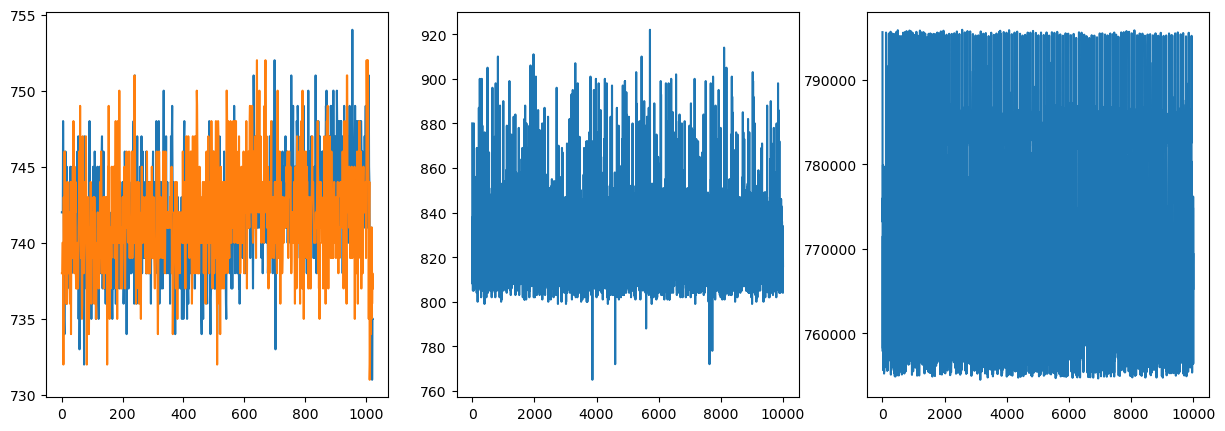

In [8]:
fig, axarr = plt.subplots(1, 3, figsize=(15, 5))

channel_0_data = e_data['ch0_data'].array()
row_max = ak.argmax(ak.max(channel_0_data, axis=0))
row_min = ak.argmin(ak.min(channel_0_data, axis=0))
axarr[0].plot(channel_0_data[row_max])
axarr[0].plot(channel_0_data[row_min])
channel_0_amp = e_data['ch0_amplitude'].array()

axarr[1].plot(channel_0_amp)

channel_0_int = e_data['ch0_integral'].array()
axarr[2].plot(channel_0_int)

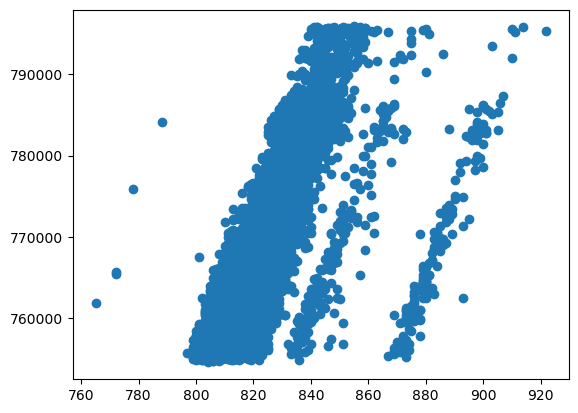

In [9]:
plt.scatter(channel_0_amp, channel_0_int)

In [10]:
max_amp = 0
in_channel = 0
for channel_num in range(16):
    amps = e_data[f'ch{channel_num}_amplitude'].array()
    max_here = ak.nanmax(amps)
    if max_here>max_amp:
        in_channel = channel_num
        max_amp = max_here
print(max_amp, in_channel)

922 0


In [11]:
import matplotlib

def filter_plot(ax, waveform, c=0, **kwargs):
    moments = np.arange(len(waveform))
    lower_quantile = np.quantile(waveform, [0.7])
    below_mask = waveform < lower_quantile
    
    colour = matplotlib.cm.tab20(c*2+1)
    ax.scatter(moments[below_mask], waveform[below_mask]-lower_quantile, c=colour, **kwargs)
    colour = matplotlib.cm.tab20(c*2)
    if 'label' in kwargs:
        kwargs.pop('label')
    ax.scatter(moments[~below_mask], waveform[~below_mask]-lower_quantile, c=colour, **kwargs)

In [12]:
import matplotlib

def averaged_peak(waveform, clip=400, bins=20):
    lower_quantile = np.quantile(waveform, [0.7])
    below_mask = np.array(waveform < lower_quantile, dtype=bool)
    below_mask[clip:] = True
    above_mask = waveform[~below_mask]-lower_quantile
    bin_len = clip//bins
    result = np.zeros(bins)
    for i in range(bins):
        start = i*bin_len
        end = min(start + bin_len, clip)
        result[i] = np.max(above_mask[start:end])
    return result
    

/data/dust/user/dayhallh/envs/calogpu/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:318: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  result.shape = shape


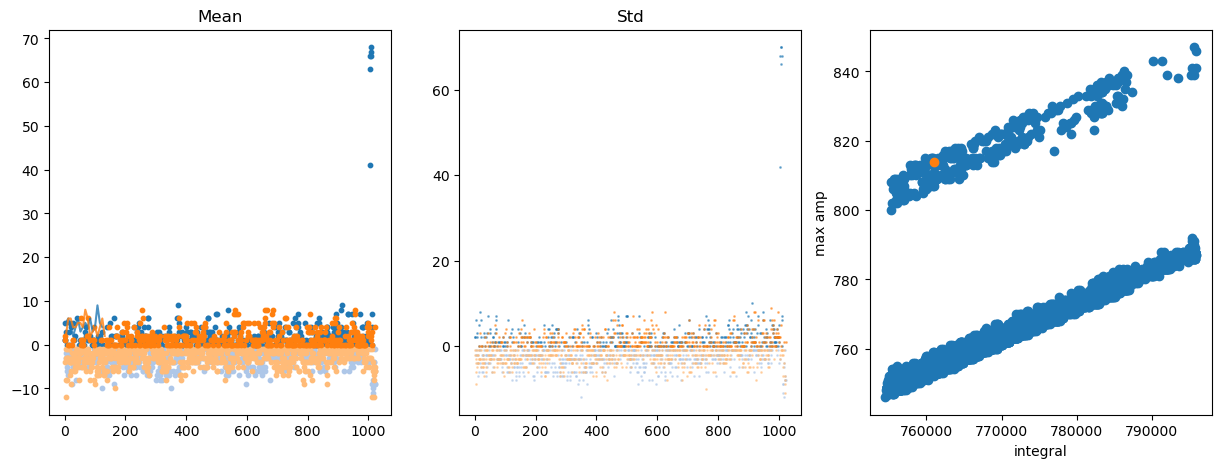

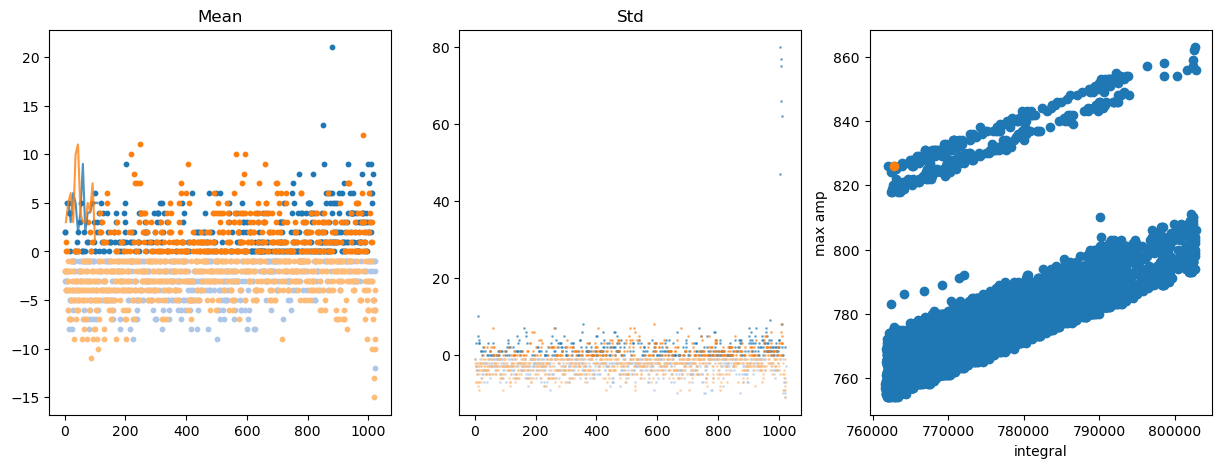

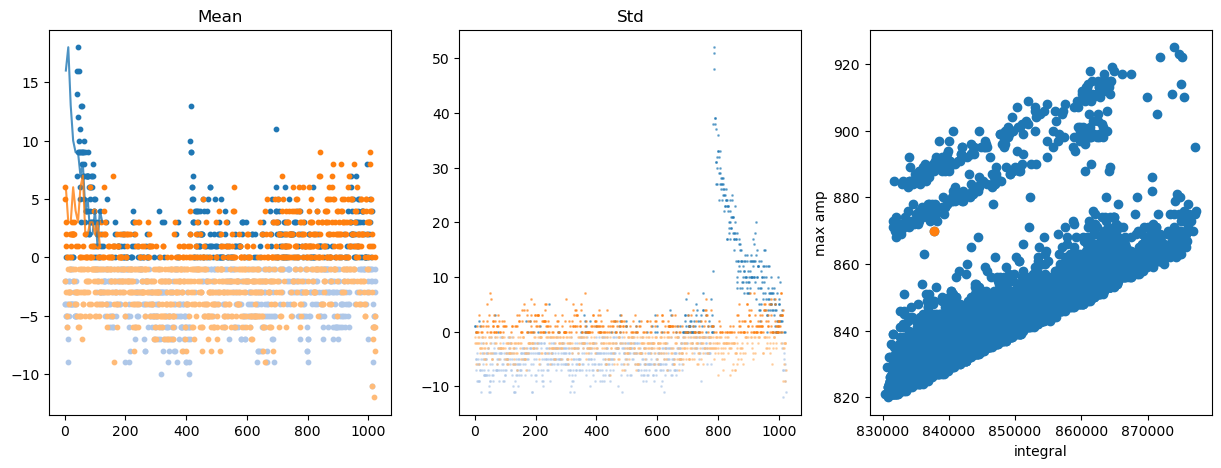

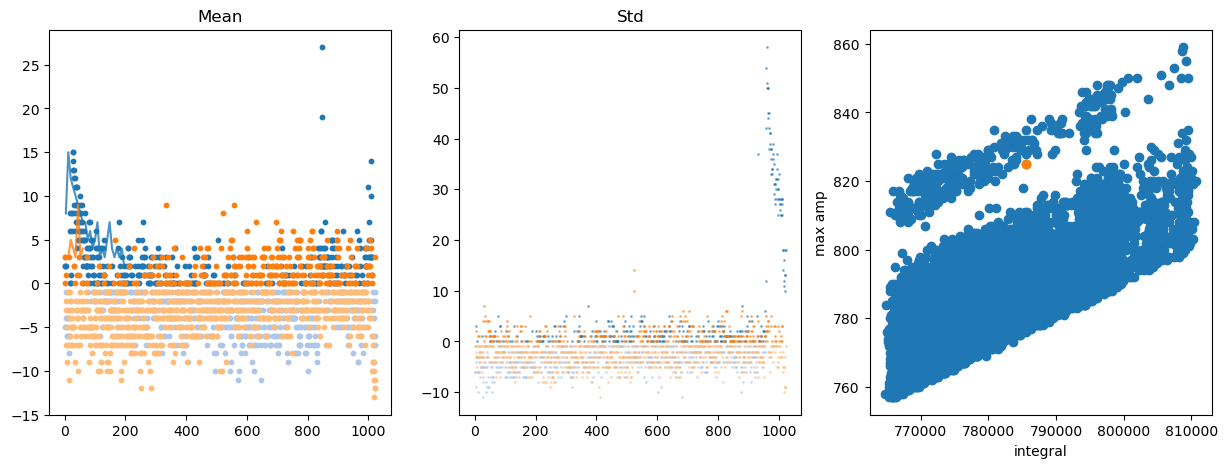

In [13]:
clip = 400
bins = 50
bin_edges = np.linspace(0, clip, bins+1)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
for i in [0, 2, 8, 11]:
    fig, axarr = plt.subplots(1, 3, figsize=(15, 5))
    
    channel_data = e_data[f'ch{i}_data'].array()
    channel_amp = ak.max(channel_data, axis=1)
    channel_mean = ak.mean(channel_data, axis=1)
    channel_std = ak.std(channel_data, axis=1)
    
    mean_max = ak.argmax(channel_mean)
    mean_min = ak.argmin(channel_mean)
    filter_plot(axarr[0], channel_data[mean_max], 0, label="max", alpha=1, s=10)
    filter_plot(axarr[0], channel_data[mean_min], 1, label="min", alpha=1, s=10)
    peaks = averaged_peak(channel_data[mean_max], clip=clip, bins=bins)
    axarr[0].plot(bin_centers, peaks, c=matplotlib.cm.tab10(0), alpha=0.8)
    peaks = averaged_peak(channel_data[mean_min], clip=clip, bins=bins)
    axarr[0].plot(bin_centers, peaks, c=matplotlib.cm.tab10(1), alpha=0.8)
    #axarr[0].legend()
    axarr[0].set_title("Mean")
    std_min = ak.argmin(channel_std)
    std_max = ak.argmax(channel_std)
    filter_plot(axarr[1], channel_data[std_max], 0, label="max", alpha=0.5, s=1)
    filter_plot(axarr[1], channel_data[std_min], 1, label="min", alpha=0.5, s=1)
    #axarr[1].legend()
    axarr[1].set_title("Std")
    
    channel_int = e_data[f'ch{i}_integral'].array()
    axarr[2].scatter(channel_int, channel_amp)
    axarr[2].scatter(channel_int[[std_max]], channel_amp[[std_max]])
    axarr[2].set_xlabel("integral")
    axarr[2].set_ylabel("max amp")

In [35]:
n_waveforms = 10_000
n_channels = 16
clip = 400
bins = 50
bin_edges = np.linspace(0, clip, bins+1)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_len = clip//bins
file_name = "peaks.npy"
if not os.path.exists(file_name):
    all_peaks = np.zeros((n_waveforms, n_channels, bins))
    
    for channel in range(n_channels):
        print(f"Channel {channel}")
        print()
        waveforms = e_data[f'ch{channel}_data'].array()
        for i, waveform in enumerate(waveforms):
            if i % 100 == 0:
                print(f"{i/10_000:.0%}", end='\r', flush=True)
                
            peak = averaged_peak(waveform, clip=clip, bins=bins)
            all_peaks[i, channel] = peak
        print()
    np.save(file_name, all_peaks)
else:
    all_peaks = np.load(file_name)
    

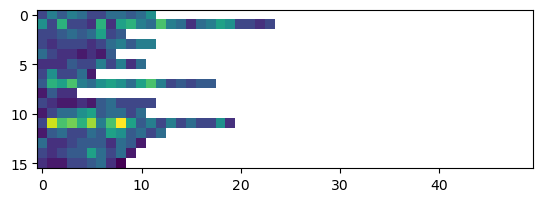

In [19]:
plt.imshow(all_peaks[:, 2])

(10000, 16, 50)


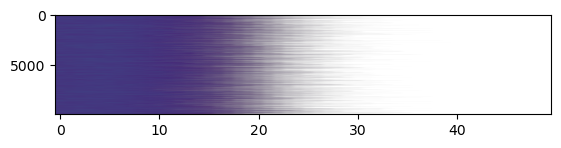

In [30]:
print(all_peaks.shape)

plt.imshow(np.nanmax(all_peaks, axis=1), aspect=0.001)

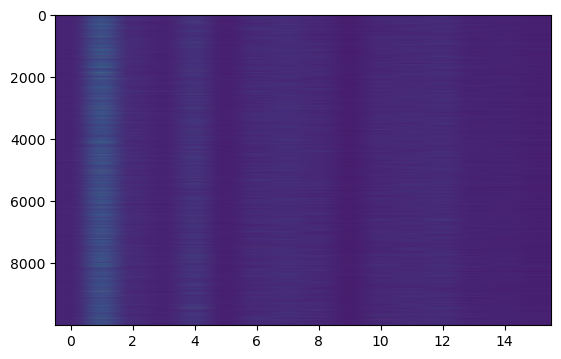

In [33]:

plt.imshow(np.nanmax(all_peaks, axis=2), aspect=0.001)

In [ ]:
plt.imshow(all_peaks[1])
